# 3D visualisation in PyGMT

[Lavayssière et al. 2019](https://www.sciencedirect.com/science/article/abs/pii/S0377027319301684?via%3Dihub#f0020) use a range of figures to show seismicity from Corbetti volcano, Ethiopia. We can replicate some of those here, using 3D plotting, and subplots to show cross-sections in depth. We'll aim to make something inspired by this figure:

![image info](./Data/Lavayssiere_fig5.png)

### Imports

In [20]:
import pygmt
import pandas as pd
import matplotlib.dates as mdates
import numpy as np

### Corbetti seismic data

If we look at the seismic locations, we can work out what the deepest event is to find our minimum elevation (or our maximum depth). 

In [21]:
eq_data = pd.read_csv('./Data/Corbetti/Corbetti_catalog.txt', sep='\t')
eq_data

,YearMonthDay,HrMinSec,Latitude,Latitude Error,Longitude,Longitude Error,Depth,Depth Error,Magnitude
0,20160216,11:40:58,7.05953,0.917074,38.4567,0.628847,7.00195,0.589946,3.013927
1,20160217,01:38:48,7.09950,0.757719,38.4849,1.021870,7.47070,1.472740,1.880876
2,20160220,02:54:06,7.06531,1.180680,38.4687,0.917897,9.49219,0.958281,2.757428
3,20160224,01:58:04,7.26169,0.718432,38.3907,0.423283,7.99805,0.227225,2.181481
4,20160224,22:49:52,7.08528,1.958420,38.4954,1.148930,2.87109,1.979490,2.278022
...,...,...,...,...,...,...,...,...,...
117,20170912,21:46:11,7.19432,0.289216,38.3935,0.504107,3.42773,0.503287,1.211208
118,20170919,01:32:43,7.18006,0.246806,38.4448,0.145049,5.68359,0.319427,1.221953
119,20170919,01:34:11,7.19637,0.750207,38.4484,0.611955,6.70898,1.731730,1.966282
120,20170919,01:41:09,7.18268,1.341640,38.4596,0.625779,3.48633,0.891875,1.286699


In [22]:
print((eq_data.Depth*-1000).min(), 'metres') # Data in file is in km

-22119.1 metres


In order to plot the data points in relation to datetime, we will need to convert those first two columns from a string into a datetime.

In [23]:
# Merge 'YearMonthDay' and 'HrMinSec' columns into a single string column, add space between
eq_data['datetime_str'] = eq_data['YearMonthDay'].astype(str) + ' ' + eq_data['HrMinSec'].astype(str)

# Convert the merged 'datetime_str' column to a pandas datetime object
eq_data['datetime'] = pd.to_datetime(eq_data['datetime_str'], format='%Y%m%d %H:%M:%S')

# Convert the datetime column to a float using mdates
eq_data['datetime_numeric'] =  mdates.date2num(eq_data['datetime'])


In [24]:
eq_data

,YearMonthDay,HrMinSec,Latitude,Latitude Error,Longitude,Longitude Error,Depth,Depth Error,Magnitude,datetime_str,datetime,datetime_numeric
0,20160216,11:40:58,7.05953,0.917074,38.4567,0.628847,7.00195,0.589946,3.013927,20160216 11:40:58,2016-02-16 11:40:58,16847.486782
1,20160217,01:38:48,7.09950,0.757719,38.4849,1.021870,7.47070,1.472740,1.880876,20160217 01:38:48,2016-02-17 01:38:48,16848.068611
2,20160220,02:54:06,7.06531,1.180680,38.4687,0.917897,9.49219,0.958281,2.757428,20160220 02:54:06,2016-02-20 02:54:06,16851.120903
3,20160224,01:58:04,7.26169,0.718432,38.3907,0.423283,7.99805,0.227225,2.181481,20160224 01:58:04,2016-02-24 01:58:04,16855.081991
4,20160224,22:49:52,7.08528,1.958420,38.4954,1.148930,2.87109,1.979490,2.278022,20160224 22:49:52,2016-02-24 22:49:52,16855.951296
...,...,...,...,...,...,...,...,...,...,...,...,...
117,20170912,21:46:11,7.19432,0.289216,38.3935,0.504107,3.42773,0.503287,1.211208,20170912 21:46:11,2017-09-12 21:46:11,17421.907072
118,20170919,01:32:43,7.18006,0.246806,38.4448,0.145049,5.68359,0.319427,1.221953,20170919 01:32:43,2017-09-19 01:32:43,17428.064387
119,20170919,01:34:11,7.19637,0.750207,38.4484,0.611955,6.70898,1.731730,1.966282,20170919 01:34:11,2017-09-19 01:34:11,17428.065405
120,20170919,01:41:09,7.18268,1.341640,38.4596,0.625779,3.48633,0.891875,1.286699,20170919 01:41:09,2017-09-19 01:41:09,17428.070243


### Designing a figure with subplots

We're going to build a figure which is made of 3 subplots. 
- The main body of the figure will be a map, with topography and locations of the earthquakes.
- There will be two subplots, on the bottom and right hand edges of the main map, which show a transect view through with depth.

![](./Data/fig_schematic.png) 

First thing to do is to define the transect points from a-A and b-B. We can vaguely lift some coordinates from the example figure that we're trying to replicate.
  

In [25]:
# Define the xprofile from a to A
a_lat = 7.205
a_lon = 38.3
A_lat = 7.19
A_lon = 38.5

num_points = 100

# Linearly interpolate latitudes and longitudes
lats = np.linspace(a_lat, A_lat, num_points)
lons = np.linspace(a_lon, A_lon, num_points)

# Combine into a DataFrame
df_coords_x = pd.DataFrame({
    "lon": lons,
    "lat": lats
})

# Show the DataFrame with 100 points
print(df_coords_x)



# repeat for yprofile, from b to B - points roughly imitating Lavayssiere et al 2019
b_lat = 7.1
b_lon = 38.405
B_lat = 7.3
B_lon = 38.42

num_points = 100

# Linearly interpolate latitudes and longitudes
lats = np.linspace(b_lat, B_lat, num_points)
lons = np.linspace(b_lon, B_lon, num_points)

# Combine into a DataFrame
df_coords_y = pd.DataFrame({
    "lon": lons,
    "lat": lats
})

# Show the DataFrame with 100 points
print(df_coords_y)

          lon       lat
0   38.300000  7.205000
1   38.302020  7.204848
2   38.304040  7.204697
3   38.306061  7.204545
4   38.308081  7.204394
..        ...       ...
95  38.491919  7.190606
96  38.493939  7.190455
97  38.495960  7.190303
98  38.497980  7.190152
99  38.500000  7.190000

[100 rows x 2 columns]
          lon       lat
0   38.405000  7.100000
1   38.405152  7.102020
2   38.405303  7.104040
3   38.405455  7.106061
4   38.405606  7.108081
..        ...       ...
95  38.419394  7.291919
96  38.419545  7.293939
97  38.419697  7.295960
98  38.419848  7.297980
99  38.420000  7.300000

[100 rows x 2 columns]


### Extracting elevation profiles
We can then use the PyGMT `grdtrack` function to extract the elevation profile of the topography along the given lat/lons, and we can plot these profiles as transects. 


In [26]:
lonmin = 38.3
lonmax = 38.5
latmin = 7.1
latmax = 7.3

# Load the topography data from in-built PyGMT 'load_earth_relief'
grid = pygmt.datasets.load_earth_relief(resolution ="01s", region=[lonmin,lonmax,latmin,latmax])

# Extract elevations from the grid for each profile, and add to dataframe as new column
xprofile = pygmt.grdtrack(points=df_coords_x, grid=grid, newcolname='xelev')
yprofile = pygmt.grdtrack(points=df_coords_y, grid=grid, newcolname='yelev')

# Print the dataframes to show the elevation points
print(xprofile)
print(yprofile)

          lon       lat        xelev
0   38.300000  7.205000  2088.000000
1   38.302020  7.204848  2095.293026
2   38.304040  7.204697  2098.833165
3   38.306061  7.204545  2107.536560
4   38.308081  7.204394  2103.659607
..        ...       ...          ...
95  38.491919  7.190606  1764.852837
96  38.493939  7.190455  1770.059955
97  38.495960  7.190303  1761.479199
98  38.497980  7.190152  1769.696244
99  38.500000  7.190000  1775.000000

[100 rows x 3 columns]
          lon       lat        yelev
0   38.405000  7.100000  1728.000000
1   38.405152  7.102020  1728.139688
2   38.405303  7.104040  1731.648502
3   38.405455  7.106061  1731.750436
4   38.405606  7.108081  1725.899143
..        ...       ...          ...
95  38.419394  7.291919  1683.807356
96  38.419545  7.293939  1681.641837
97  38.419697  7.295960  1679.135395
98  38.419848  7.297980  1677.055916
99  38.420000  7.300000  1678.000000

[100 rows x 3 columns]


Just as we found the maximum depth of the seismicity, to constrain the z axis of the plot, print the maximum elevation in the topography transects

In [27]:
# Print max for xprofile and yprofile
print(np.amax(xprofile), 'metres')
print(np.amax(yprofile), 'metres')


2153.9171341 metres
1928.90475293 metres


### Building our figure
Traditionally, PyGMT figures are built from the bottom left of the page (marked, x (0,0) in the schematic figure). In practice, this means we need to plot the bottom subplot first, then shift our coordinate axes up the page, to plot the main figure, and then shift our plot axes to the right, to plot the final transect subplot - ie. subplot 1, 2, 3 as marked. 

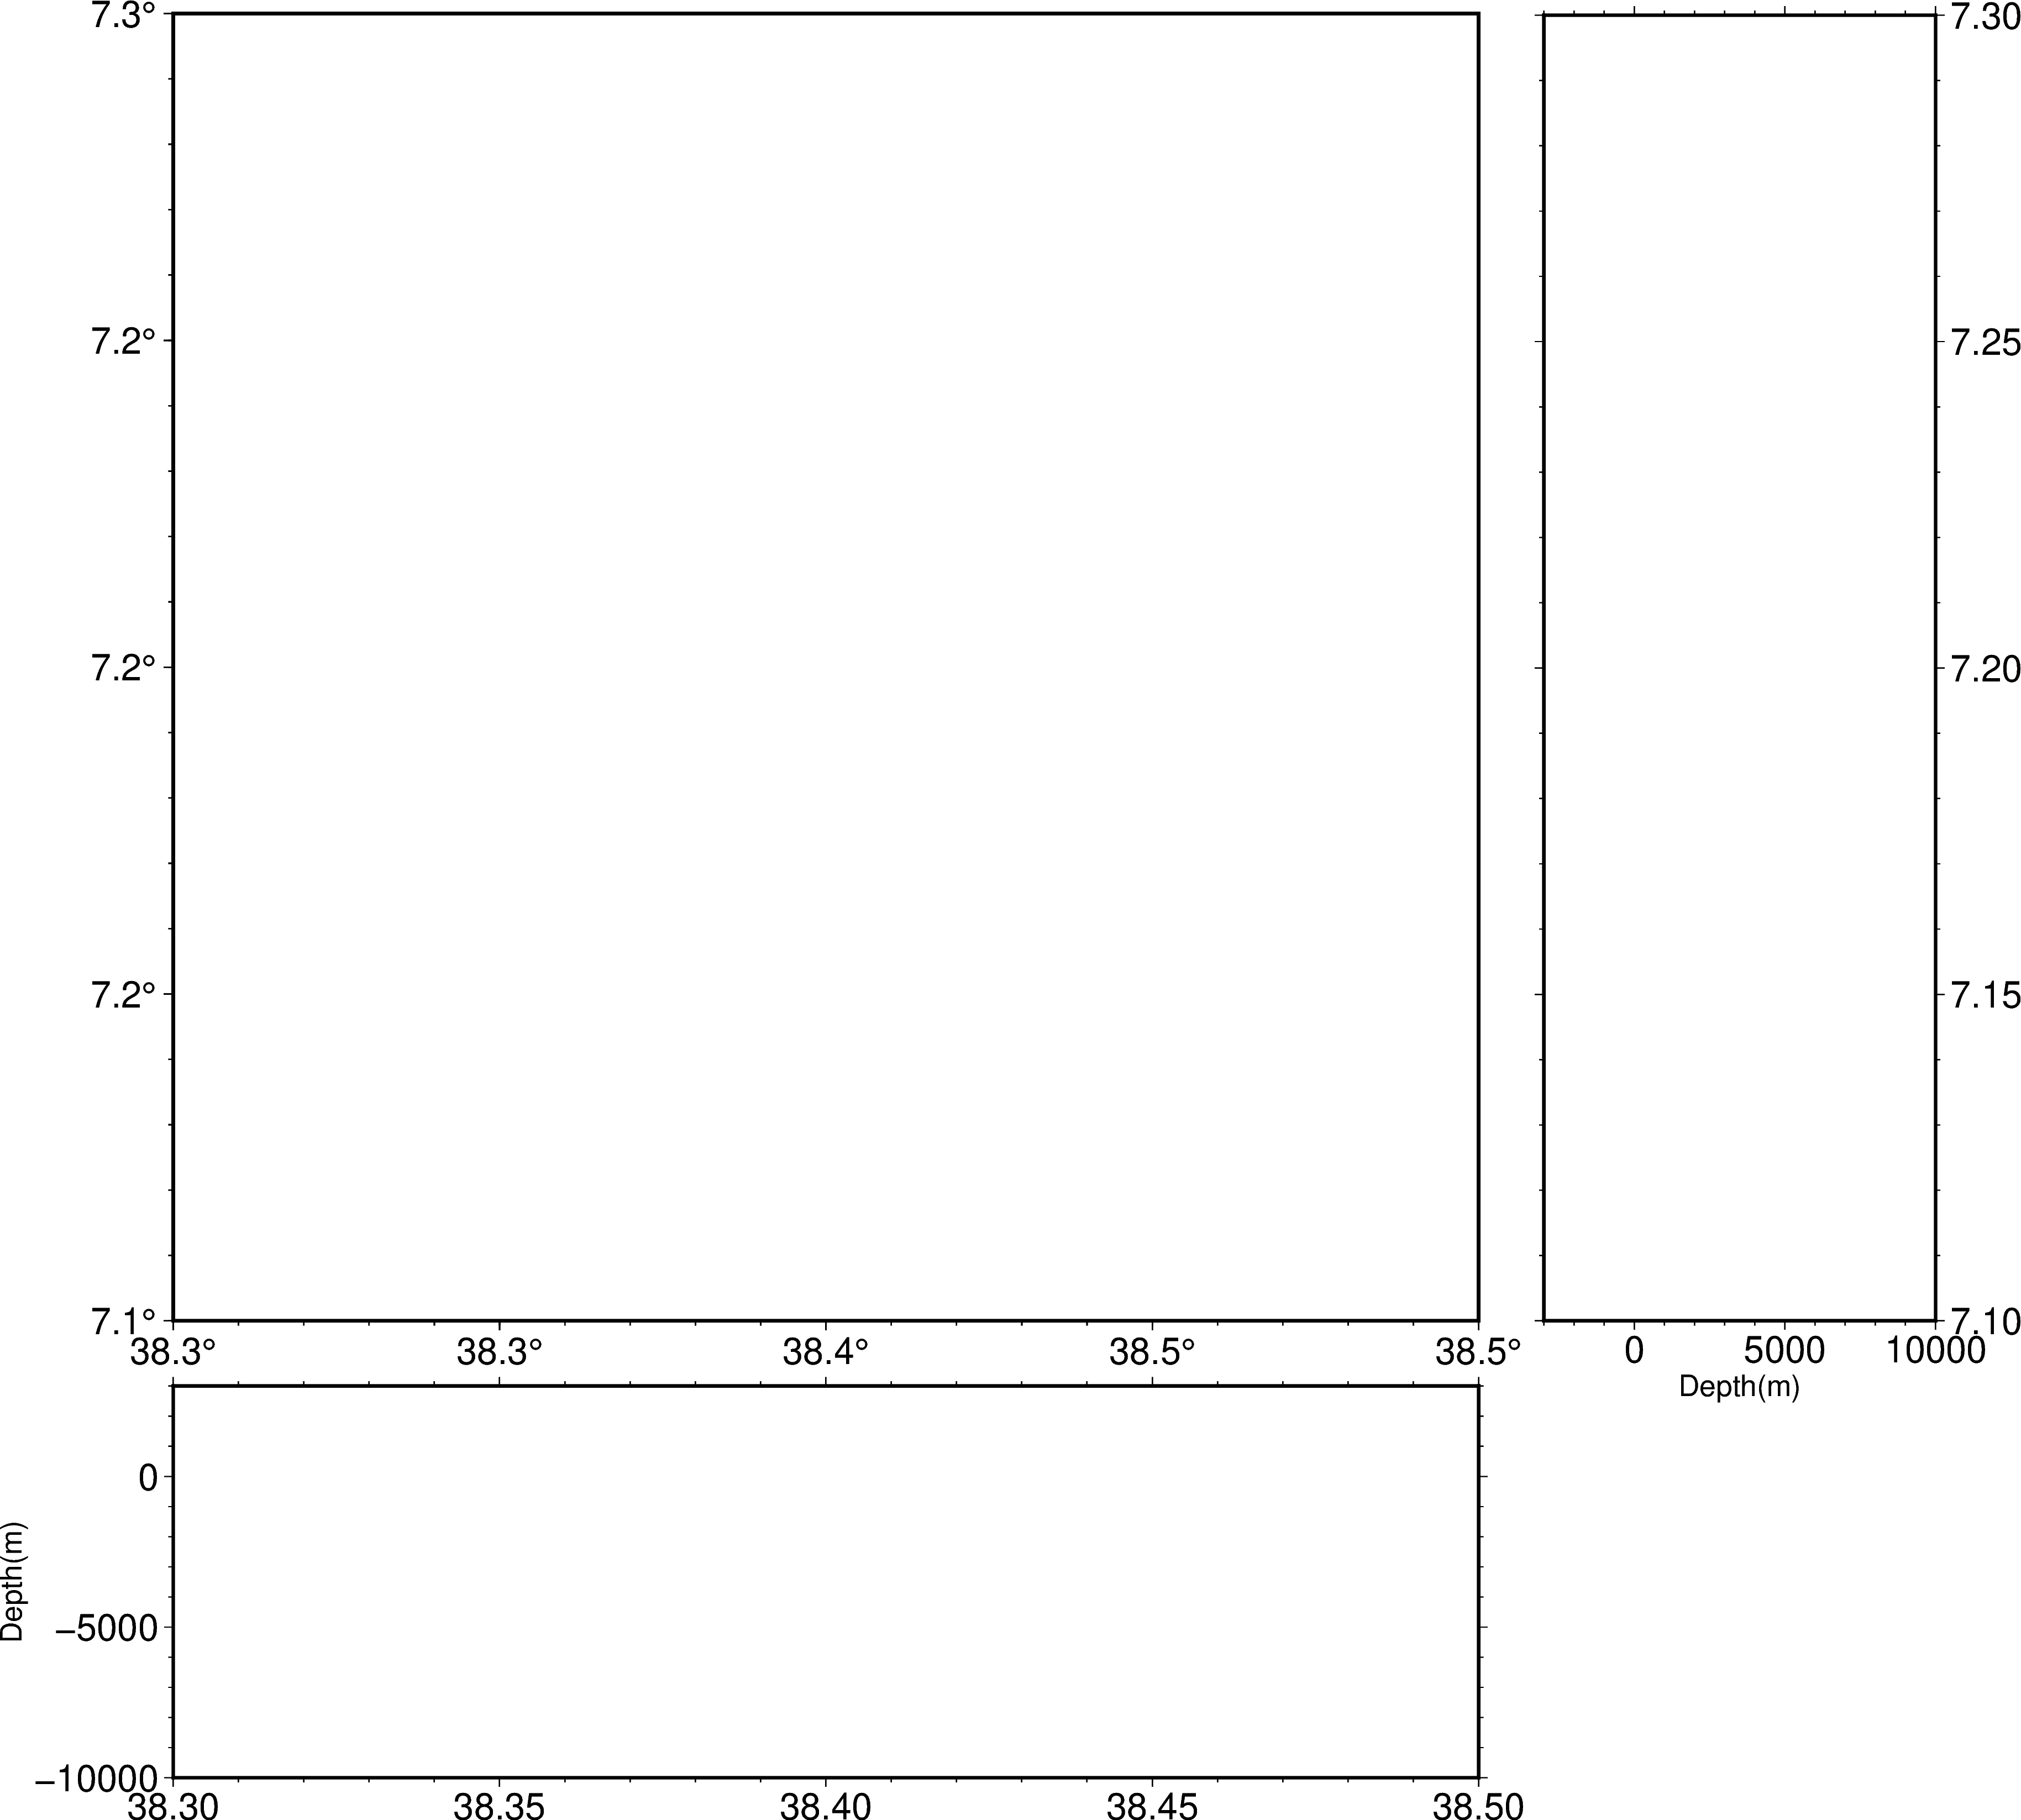

In [28]:
# Define main plot region
lonmin = 38.3
lonmax = 38.5
latmin = 7.1
latmax = 7.3

# Define the boundaries in the z direction
elevmin = -10000
elevmax = 3000

# Define a map projection for the main map
proj="M20c"

# Initiate the figure instance 
fig = pygmt.Figure()

# Set up some configuration parameters
pygmt.config(FONT_ANNOT_PRIMARY="16p", FONT_TITLE='16p')
pygmt.config(FORMAT_GEO_MAP="ddd.x", MAP_FRAME_TYPE="plain")

# Download 1 arc second topography into a variable called grid. Calculate the grid gradient. Define a colormap for grid
grid = pygmt.datasets.load_earth_relief(resolution ="01s", region=[lonmin,lonmax,latmin,latmax])
dgrid = pygmt.grdgradient(grid=grid, radiance=[270, 30])
cmap_grid = pygmt.makecpt(cmap="grayC", series=[-1.5,1.5,0.1])

# Define 3 variables which describe the "frame" for each subplot
xframe = ["ya5000f1000+lDepth(m)", "xa0.05f0.01", "WSne"]
mainframe = "a0.05f0.01"
yframe = ["xa5000f1000+lDepth(m)", "ya0.05f0.01", "wSnE"]

# Initiate the first subplot
with fig.subplot(nrows=1, ncols=1, figsize=("20c", "6c")):
    fig.basemap(region=[lonmin,lonmax,elevmin,elevmax], projection="X?", frame=xframe)


# Shift the y axis up by 7c, to clear the 6cm tall plot with 1c clearance, and create the frame for second subplot
fig.shift_origin(yshift="7c")    
with fig.subplot(nrows=1, ncols=1, figsize=("20c", "20c")):
    fig.basemap(region=[lonmin,lonmax,latmin,latmax], projection=proj, frame=[mainframe])

    
# Shift the axis by 20cm, plus 1cm clearance to initiate the third subplot
fig.shift_origin(xshift="21c")
with fig.subplot(nrows=1, ncols=1, figsize=("6c", "20c")):
    fig.basemap(region=[-elevmax, -elevmin, latmin, latmax], projection="X?", frame=yframe)

fig.show()

### Adding details 

legend [WARNING]: Your -D option was interpreted to mean -Dx


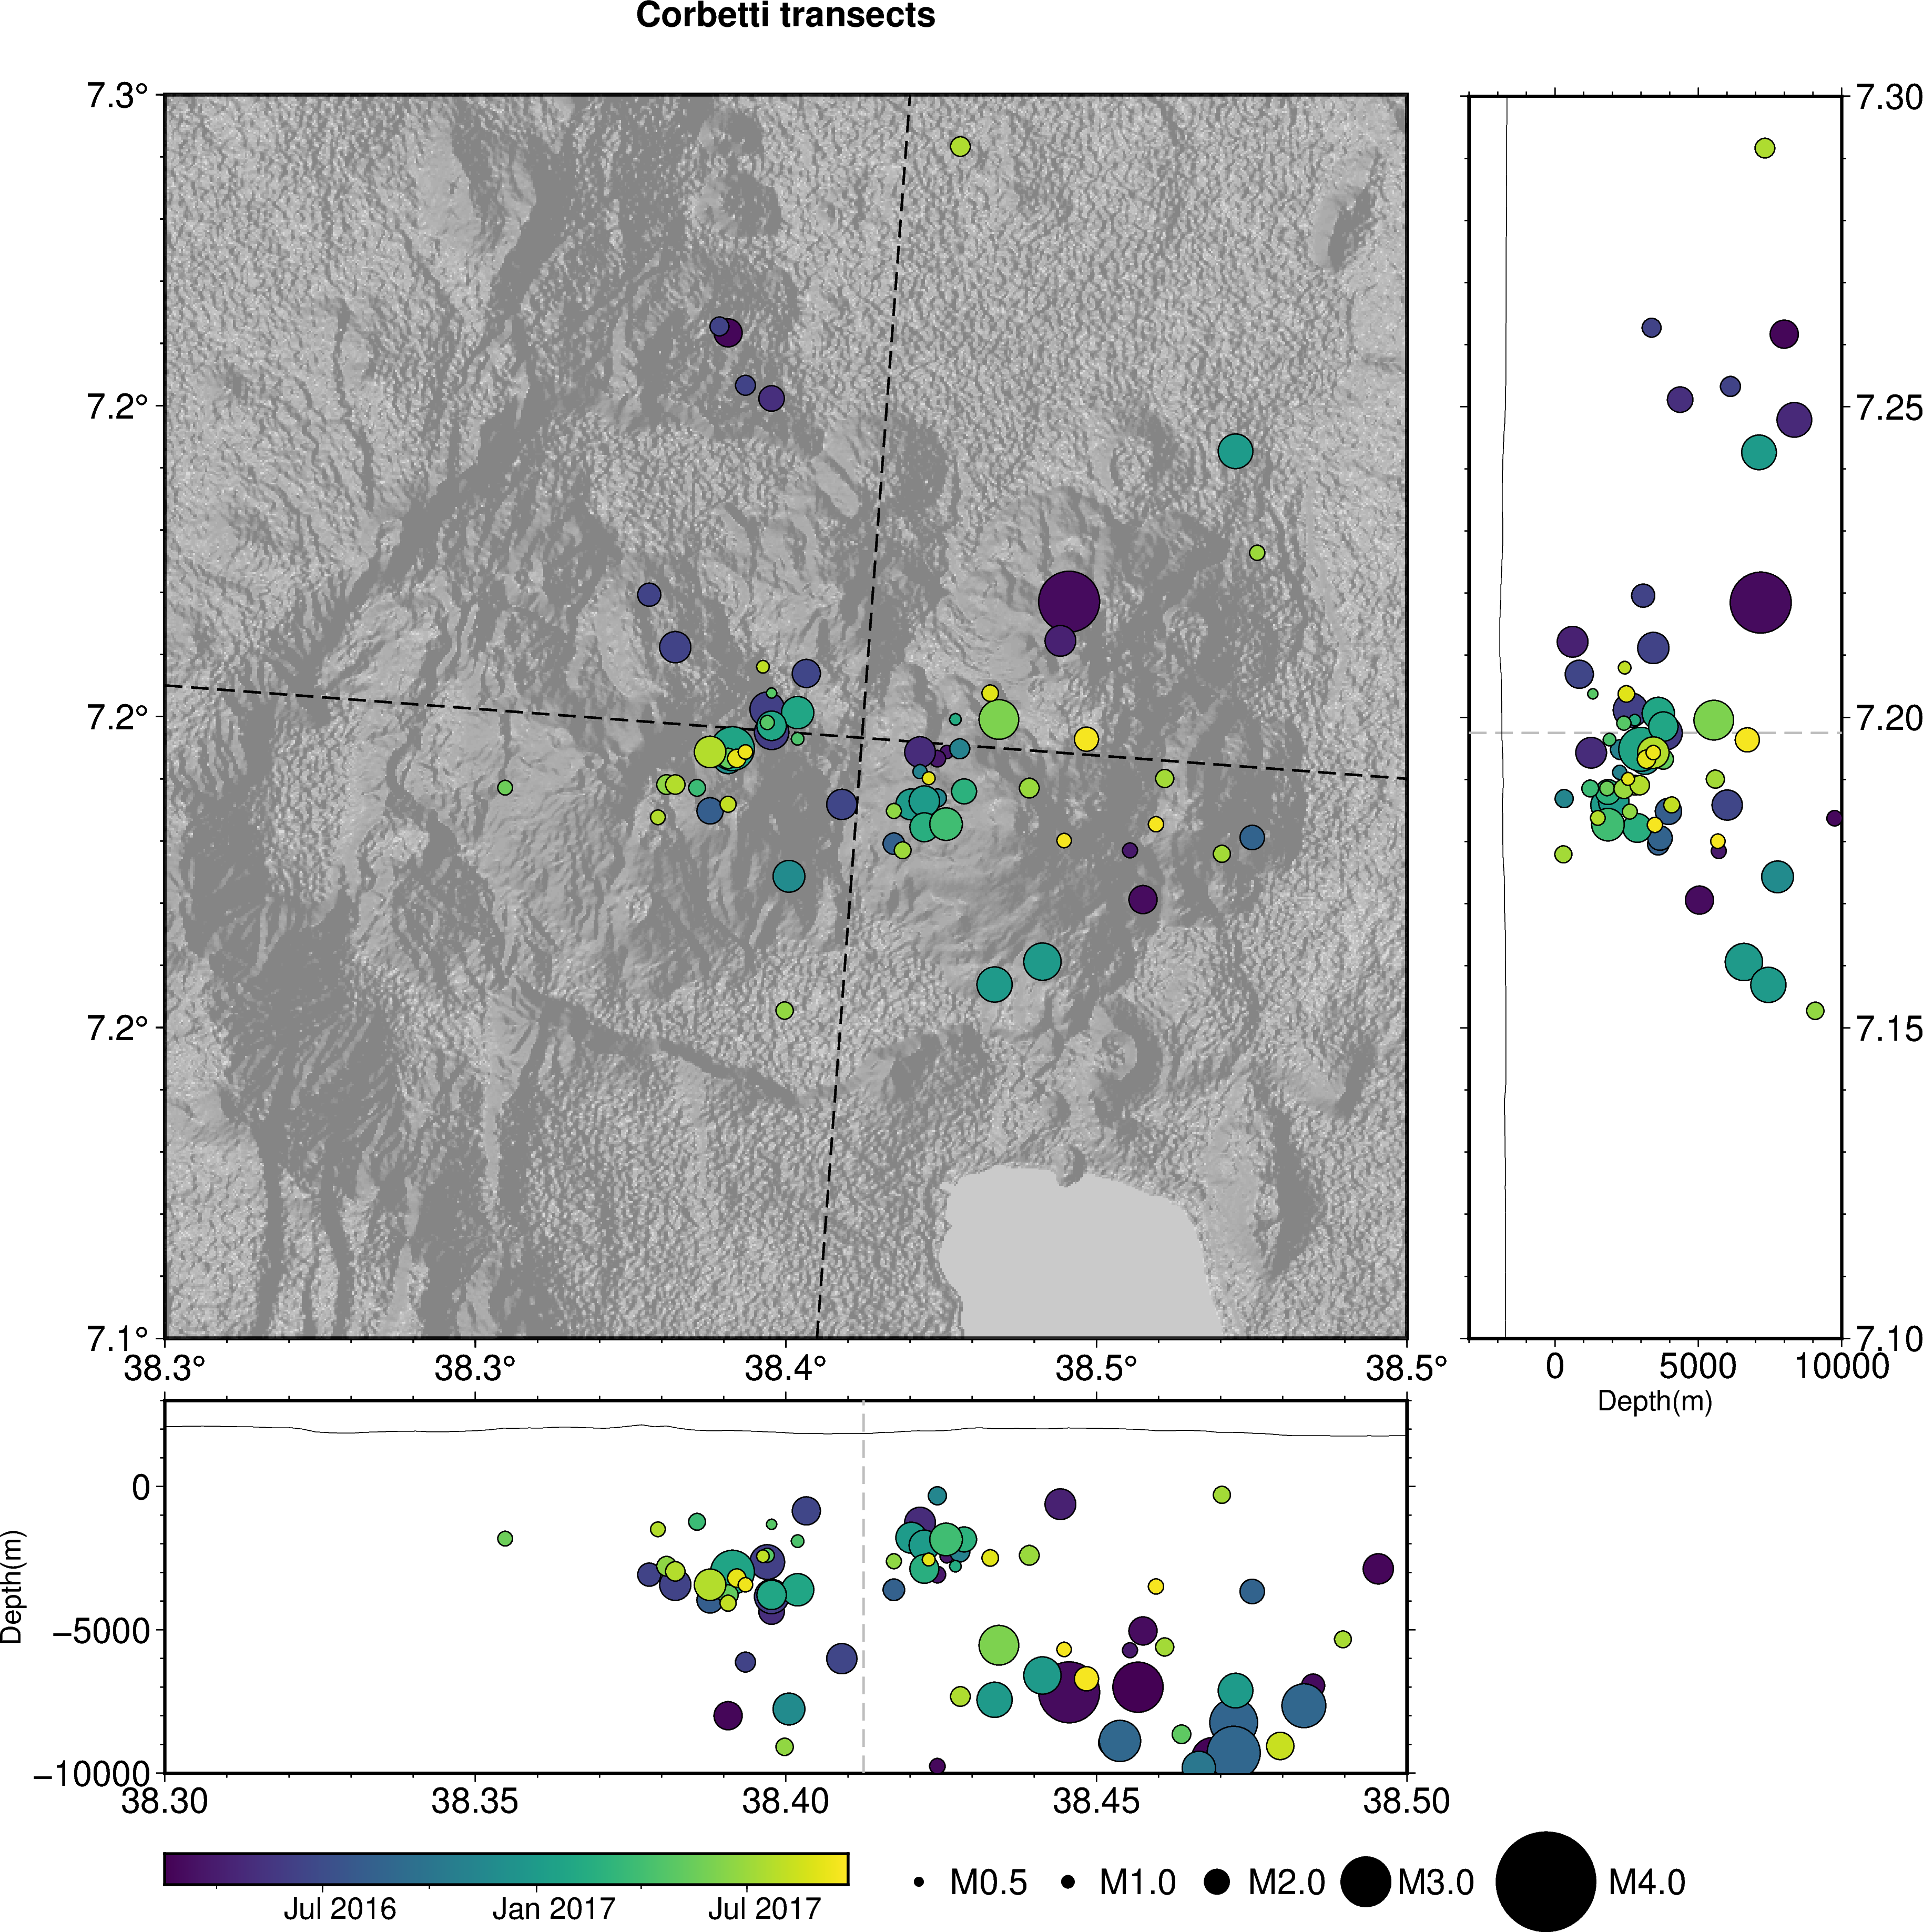

In [29]:
# Define main plot region
lonmin = 38.3
lonmax = 38.5
latmin = 7.1
latmax = 7.3

# Define the boundaries in the z direction
elevmin = -10000
elevmax = 3000

# Define a map projection for the main map
proj="M20c"

# Initiate the figure instance 
fig = pygmt.Figure()

# Set up some configuration parameters
pygmt.config(FONT_ANNOT_PRIMARY="16p", FONT_TITLE='16p')
pygmt.config(FORMAT_GEO_MAP="ddd.x", MAP_FRAME_TYPE="plain")

# Download 1 arc second topography into a variable called grid. Calculate the grid gradient. Define a colormap for grid
grid = pygmt.datasets.load_earth_relief(resolution ="01s", region=[lonmin,lonmax,latmin,latmax])
dgrid = pygmt.grdgradient(grid=grid, radiance=[270, 30])

# Define 3 variables which describe the "frame" for each subplot
xframe = ["ya5000f1000+lDepth(m)", "xa0.05f0.01", "WSne"]
mainframe = "a0.05f0.01"
yframe = ["xa5000f1000+lDepth(m)", "ya0.05f0.01", "wSnE"]

# Initiate the first subplot
with fig.subplot(nrows=1, ncols=1, figsize=("20c", "6c")):
    fig.basemap(region=[lonmin,lonmax,elevmin,elevmax], projection="X?", frame=xframe)
    fig.plot(x=[(B_lon+b_lon)/2., (B_lon+b_lon)/2.], y=[elevmin,elevmax], pen='1p,gray,dash', projection="X?")
    fig.plot(x=xprofile.lon, y=xprofile.xelev)
    pygmt.makecpt(cmap="viridis", series=[eq_data['datetime'].min(), eq_data['datetime'].max()])
    fig.plot(x=eq_data.Longitude, y=(eq_data.Depth)*-1000., style='cc', size=0.1*(2**eq_data.Magnitude), pen='0.5p,black', cmap=True, fill=eq_data['datetime'])
    fig.colorbar(frame="af",position="x0c/-1.8c+w11c/0.5c+h", scale=1, region=[lonmin,lonmax,elevmin,elevmax], projection='X?')   
    fig.legend(spec='legend.txt', position='12.0c/-2.2c+w12c')

# Shift the y axis up by 7c, to clear the 6cm tall plot with 1c clearance, and create the frame for second subplot
fig.shift_origin(yshift="7c")    
with fig.subplot(nrows=1, ncols=1, figsize=("20c", "20c")):
    titlestr ="Corbetti transects"
    title = "+t\""+titlestr+"\""
    fig.basemap(region=[lonmin,lonmax,latmin,latmax], projection=proj, frame=[mainframe, title])
    pygmt.makecpt(cmap="grayC", series=[-1.5,1.5,0.1])
    fig.grdimage(grid=dgrid, projection=proj, frame =mainframe, cmap=True, transparency=40)
    fig.plot(x=[a_lon, A_lon], y=[a_lat, A_lat], pen='1p,black,dash', projection=proj)  
    fig.plot(x=[b_lon, B_lon], y=[b_lat, B_lat], pen='1p,black,dash', projection=proj)    
    pygmt.makecpt(cmap="viridis", series=[eq_data['datetime'].min(), eq_data['datetime'].max()])
    fig.plot(x=eq_data.Longitude, y=eq_data.Latitude, style='cc', size=0.1*(2**eq_data.Magnitude), pen='0.5p,black', cmap=True, fill=eq_data['datetime'], projection=proj)
    
# Shift the axis by 20cm, plus 1cm clearance to initiate the third subplot
fig.shift_origin(xshift="21c")
with fig.subplot(nrows=1, ncols=1, figsize=("6c", "20c")):
    fig.basemap(region=[-elevmax, -elevmin, latmin, latmax], projection="X?", frame=yframe)
    fig.plot(x=[-elevmax, -elevmin], y=[(A_lat+a_lat)/2., (A_lat+a_lat)/2.], pen='1p,gray,dash', projection="X?")
    fig.plot(x=-yprofile.yelev, y=yprofile.lat)
    pygmt.makecpt(cmap="viridis", series=[eq_data['datetime'].min(), eq_data['datetime'].max()])
    fig.plot(x=(eq_data.Depth)*1000, y=eq_data.Latitude, style='cc', size=0.1*(2**eq_data.Magnitude), pen='0.5p,black', cmap=True, fill=eq_data['datetime'])

fig.show()